# Customer Job-Change Prediction: Efficient DataFrame Storage

![Two data scientists working on a dashboard.](hr-image-small.png)

## Project Overview

A common problem when creating models to generate business value from data is that the datasets can be so large that it can take days for the model to generate predictions. Ensuring that your dataset is stored as efficiently as possible is crucial for allowing these models to run on a more reasonable timescale without having to reduce the size of the dataset.

**Client:** Training Data Ltd. — a major online data science training provider  
**Goal:** Optimize memory usage of `customer_train.csv` (19,158 rows × 14 columns) by applying correct pandas dtypes before using the data for job-change prediction modeling.

The dataset contains anonymized student information, and whether they were looking for a new job or not during training:

| Column                   | Description                                                                      |
|------------------------- |--------------------------------------------------------------------------------- |
| `student_id`             | A unique ID for each student.                                                    |
| `city`                   | A code for the city the student lives in.                                        |
| `city_development_index` | A scaled development index for the city.                                         |
| `gender`                 | The student's gender.                                                            |
| `relevant_experience`    | An indicator of the student's work relevant experience.                          |
| `enrolled_university`    | The type of university course enrolled in (if any).                              |
| `education_level`        | The student's education level.                                                   |
| `major_discipline`       | The educational discipline of the student.                                       |
| `experience`             | The student's total work experience (in years).                                  |
| `company_size`           | The number of employees at the student's current employer.                       |
| `company_type`           | The type of company employing the student.                                       |
| `last_new_job`           | The number of years between the student's current and previous jobs.             |
| `training_hours`         | The number of hours of training completed.                                       |
| `job_change`             | An indicator of whether the student is looking for a new job (`1`) or not (`0`). |

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds_jobs = pd.read_csv("customer_train.csv")
ds_jobs.head()

,student_id,city,city_development_index,gender,relevant_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,job_change
0,8949,city_103,0.920,Male,Has relevant experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevant experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevant experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevant experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevant experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 2. Transformation Pipeline

A `DataTransformer` class handles all dtype conversions in a clean, chainable pipeline.

| Step | Method              | What it does                                                        |
|------|---------------------|---------------------------------------------------------------------|
| 1    | `convert_bool()`    | `relevant_experience`, `job_change` → `bool`                       |
| 2    | `convert_num()`     | integers → `int32`, floats → `float16`                             |
| 3    | `convert_nom_cat()` | `city`, `gender`, `major_discipline`, `company_type` → `category`  |
| 4    | `convert_ord_cat()` | `experience`, `education_level`, etc. → ordered `category`         |
| 5    | `filter_data()`     | Keep only 10+ yrs experience & 1000+ employee companies            |

In [3]:
class DataTransformer:
    def __init__(self, df):
        self.df = df.copy()
        self.ord_mappings = {
            'enrolled_university': ['no_enrollment', 'Part time course', 'Full time course'],
            'education_level': ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd'],
            'experience': ['<1'] + [str(i) for i in range(1, 21)] + ['>20'],
            'company_size': ['<10', '10-49', '50-99', '100-499', '500-999',
                            '1000-4999', '5000-9999', '10000+'],
            'last_new_job': ['never', '1', '2', '3', '4', '>4']
        }

    def convert_bool(self):
        """Convert binary columns to bool dtype."""
        self.df['relevant_experience'] = self.df['relevant_experience'] == 'Has relevant experience'
        self.df['job_change'] = self.df['job_change'].astype('bool')
        return self

    def convert_num(self):
        """Downcast integer and float columns to reduce memory usage."""
        self.df['student_id'] = self.df['student_id'].astype('int32')
        self.df['training_hours'] = self.df['training_hours'].astype('int32')
        self.df['city_development_index'] = self.df['city_development_index'].astype('float16')
        return self

    def convert_nom_cat(self):
        """Convert nominal categorical columns (no natural order) to category dtype."""
        cols = ['city', 'gender', 'major_discipline', 'company_type']
        for col in cols:
            self.df[col] = self.df[col].astype('category')
        return self

    def convert_ord_cat(self):
        """Convert ordinal categorical columns to ordered category dtype, preserving natural order."""
        for col, order in self.ord_mappings.items():
            if col in self.df.columns:
                existing = self.df[col].dropna().unique()
                categories = [c for c in order if c in existing]
                self.df[col] = pd.Categorical(self.df[col], categories=categories, ordered=True)
        return self

    def filter_data(self):
        """Filter to students with 10+ years experience at companies with 1000+ employees."""
        experience_filter = self.df['experience'] >= '10'
        company_size_filter = self.df['company_size'] >= '1000-4999'
        self.df = self.df[experience_filter & company_size_filter]
        return self

    def get_result(self):
        """Return the transformed DataFrame with reset index."""
        return self.df.reset_index(drop=True)

## 3. Apply Transformations Step by Step

In [4]:
# Step 1: Boolean conversion
transform = DataTransformer(ds_jobs)
transform.convert_bool()
transform.df[['relevant_experience', 'job_change']].head()

,relevant_experience,job_change
0,True,True
1,False,False
2,False,False
3,False,True
4,True,False


In [5]:
# Step 2: Numeric downcast
transform.convert_num()
transform.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              19158 non-null  int32  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float16
 3   gender                  14650 non-null  object 
 4   relevant_experience     19158 non-null  bool   
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int32  
 13  job_change              19158 non-null  bool   
dtypes: bool(2), float16(1), int32(2), obje

In [6]:
# Step 3: Nominal categorical conversion
transform.convert_nom_cat()
transform.df.select_dtypes('category').head()

,city,gender,major_discipline,company_type
0,city_103,Male,STEM,NaN
1,city_40,Male,STEM,Pvt Ltd
2,city_21,NaN,STEM,NaN
3,city_115,NaN,Business Degree,Pvt Ltd
4,city_162,Male,STEM,Funded Startup


In [7]:
# Step 4 & 5: Ordinal categorical conversion + filter
transform.convert_ord_cat()
transform.filter_data()

## 4. Results

In [8]:
ds_jobs_transformed = transform.get_result()
ds_jobs_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   student_id              2201 non-null   int32   
 1   city                    2201 non-null   category
 2   city_development_index  2201 non-null   float16 
 3   gender                  1821 non-null   category
 4   relevant_experience     2201 non-null   bool    
 5   enrolled_university     2185 non-null   category
 6   education_level         2184 non-null   category
 7   major_discipline        2097 non-null   category
 8   experience              2201 non-null   category
 9   company_size            2201 non-null   category
 10  company_type            2144 non-null   category
 11  last_new_job            2184 non-null   category
 12  training_hours          2201 non-null   int32   
 13  job_change              2201 non-null   bool    
dtypes: bool(2), category(9),

## 5. Memory Usage Comparison

In [9]:
og_mem = ds_jobs.memory_usage(deep=True).sum()
rm_mem = ds_jobs_transformed.memory_usage(deep=True).sum()

print("Original DataFrame memory usage:")
print(og_mem, "bytes")

print("\nTransformed DataFrame memory usage:")
print(rm_mem, "bytes")

print("\nMemory reduction:")
print(f"{(1 - rm_mem / og_mem) * 100:.1f}%")

Original DataFrame memory usage:
11024933 bytes

Transformed DataFrame memory usage:
62416 bytes

Memory reduction:
99.4%


## 6. Visualization

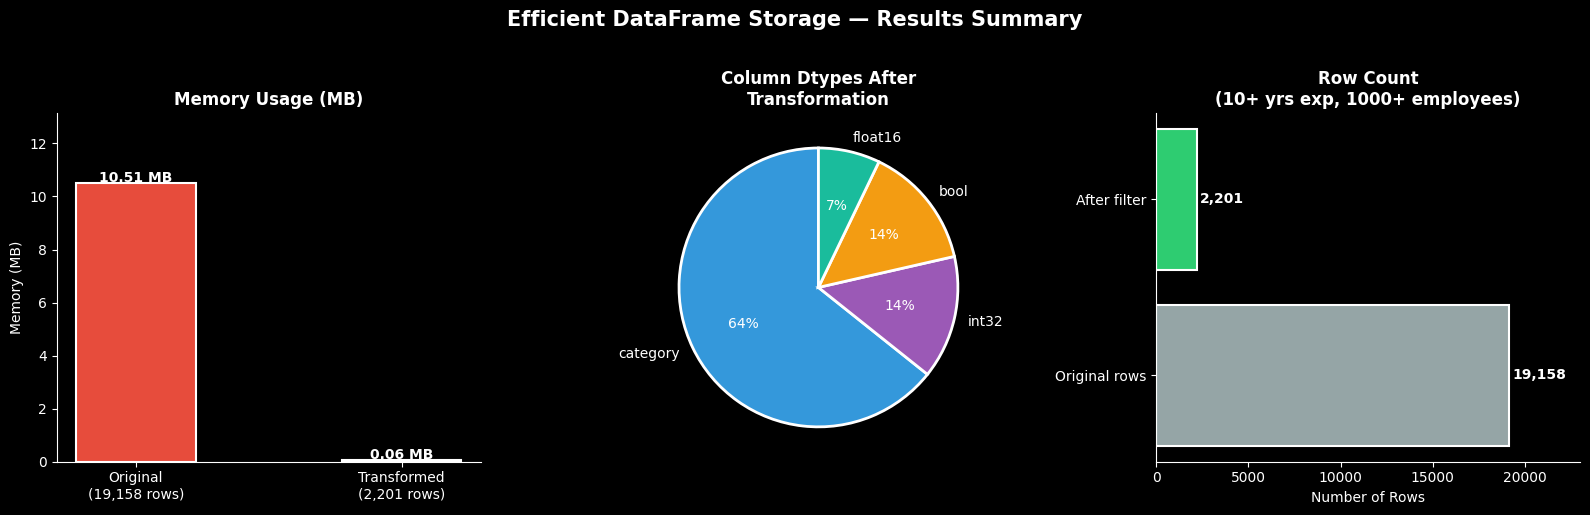

✅ Memory reduced by 99.4% — from 10.5 MB to 61.0 KB


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Efficient DataFrame Storage — Results Summary', fontsize=15, fontweight='bold', y=1.02)

# --- Plot 1: Memory bar chart ---
mem_labels = ['Original\n(19,158 rows)', 'Transformed\n(2,201 rows)']
mem_values = [og_mem / 1024**2, rm_mem / 1024**2]
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(mem_labels, mem_values, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
axes[0].set_title('Memory Usage (MB)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Memory (MB)')
axes[0].set_ylim(0, max(mem_values) * 1.25)

for bar, val in zip(bars, mem_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                 f'{val:.2f} MB', ha='center', fontsize=10, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot 2: Dtype distribution after transformation ---
dtype_counts = ds_jobs_transformed.dtypes.astype(str).value_counts()
palette = ['#3498db', '#9b59b6', '#f39c12', '#1abc9c']
axes[1].pie(
    dtype_counts.values,
    labels=dtype_counts.index,
    autopct='%1.0f%%',
    colors=palette[:len(dtype_counts)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Column Dtypes After\nTransformation', fontsize=12, fontweight='bold')

# --- Plot 3: Filtered dataset summary ---
row_labels = ['Original rows', 'After filter']
row_counts = [len(ds_jobs), len(ds_jobs_transformed)]
bar_colors = ['#95a5a6', '#2ecc71']
bars2 = axes[2].barh(row_labels, row_counts, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Row Count\n(10+ yrs exp, 1000+ employees)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Rows')

for bar, val in zip(bars2, row_counts):
    axes[2].text(bar.get_width() + 150,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10, fontweight='bold')

axes[2].set_xlim(0, max(row_counts) * 1.2)
axes[2].spines[['top', 'right']].set_visible(False)

plt.style.use('dark_background')
plt.tight_layout()
plt.savefig('memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Memory reduced by {(1 - rm_mem / og_mem) * 100:.1f}% — from {og_mem/1024**2:.1f} MB to {rm_mem/1024:.1f} KB")

## 7. Filtered Dataset Summary

In [11]:
print("=" * 50)
print("Filtered Dataset Summary")
print("=" * 50)
print(f"Rows remaining : {len(ds_jobs_transformed):,} / {len(ds_jobs):,} ({len(ds_jobs_transformed)/len(ds_jobs)*100:.1f}%)")
print(f"Columns        : {ds_jobs_transformed.shape[1]}")

print("\nExperience distribution (10+ years only):")
print(ds_jobs_transformed['experience'].value_counts().sort_index().to_string())

print("\nCompany size distribution (1000+ employees only):")
print(ds_jobs_transformed['company_size'].value_counts().sort_index().to_string())

print("\nJob change rate in filtered group:")
rate = ds_jobs_transformed['job_change'].mean() * 100
print(f"{rate:.1f}% are looking for a new job")

Filtered Dataset Summary
Rows remaining : 2,201 / 19,158 (11.5%)
Columns        : 14

Experience distribution (10+ years only):
experience
<1       0
1        0
2        0
3        0
4        0
5        0
6        0
7        0
8        0
9        0
10     245
11     149
12     107
13     103
14     147
15     172
16     128
17      91
18      68
19      83
20      49
>20    859

Company size distribution (1000+ employees only):
company_size
<10             0
10-49           0
50-99           0
100-499         0
500-999         0
1000-4999     796
5000-9999     310
10000+       1095

Job change rate in filtered group:
13.3% are looking for a new job
